<a href="https://colab.research.google.com/github/ddezouza/Data201_DanielaMelo/blob/main/DanielaMelo_Week4Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Loading

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")

### Part E - Explore the Dataset

Create at least three plots such as:

- Histogram of price
- Scatterplot of size vs. price
- Boxplot: price by neighborhood
- Barchart: housing type

In [6]:
df.describe()

,listing_id,price,size,bedrooms
count,600.000000,600.000000,547.000000,576.000000
mean,100300.500000,201053.488333,1763.208584,2.244792
std,173.349358,34175.725330,701.737347,1.308490
min,100001.000000,96746.000000,607.197941,0.000000
25%,100150.750000,175044.250000,1285.926707,1.000000
50%,100300.500000,201165.000000,1626.257658,2.000000
75%,100450.250000,226874.000000,2081.737227,3.000000
max,100600.000000,282086.000000,4500.000000,6.000000


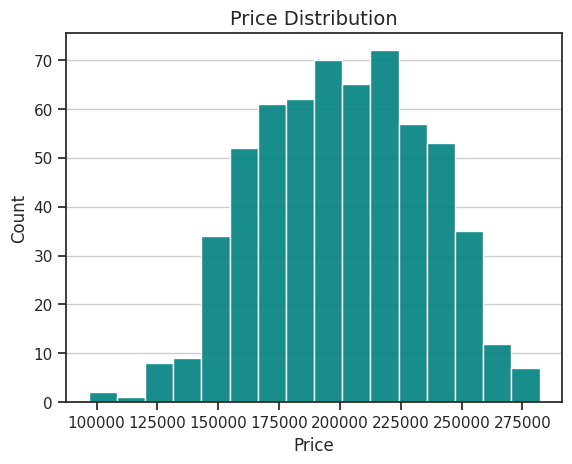

In [11]:
#Histogram price
sns.set_theme(style='ticks')
sns.histplot(data=df,x='price',kde=False, alpha=.90, color='teal')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Price Distribution", fontsize=14)
plt.grid(True, axis='y',zorder=0)
plt.show()

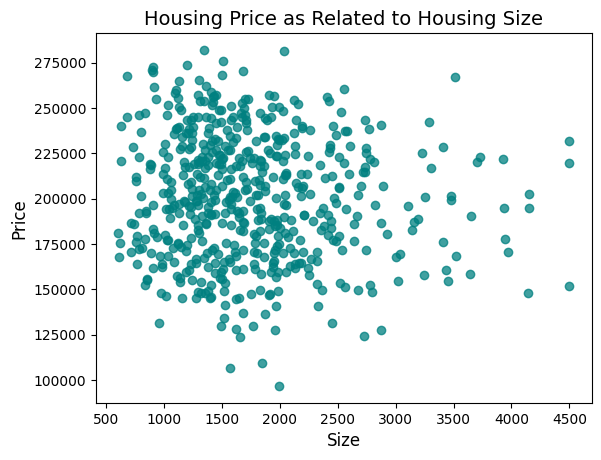

In [9]:
#Scatterplot of size vs price
plt.scatter(df['size'], df['price'], color='teal', alpha=0.75)
plt.xlabel('Size', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title("Housing Price as Related to Housing Size", fontsize=14)
plt.show()

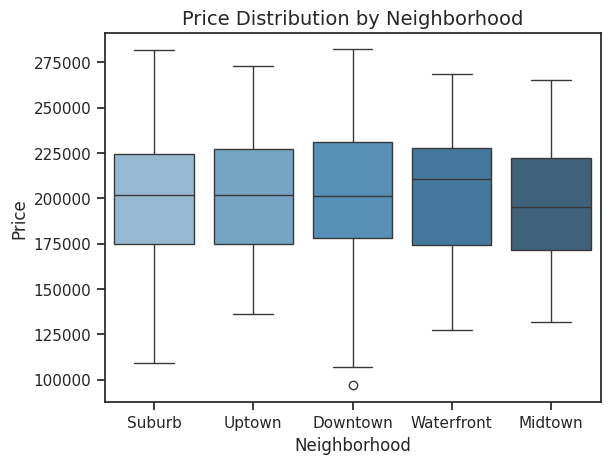

In [12]:
#Boxplot Price by Neighborhood
sns.set_palette('Blues_d')
sns.boxplot(data=df,x='neighborhood',y='price', hue='neighborhood')
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title("Price Distribution by Neighborhood", fontsize=14)
plt.grid(False)
plt.show()

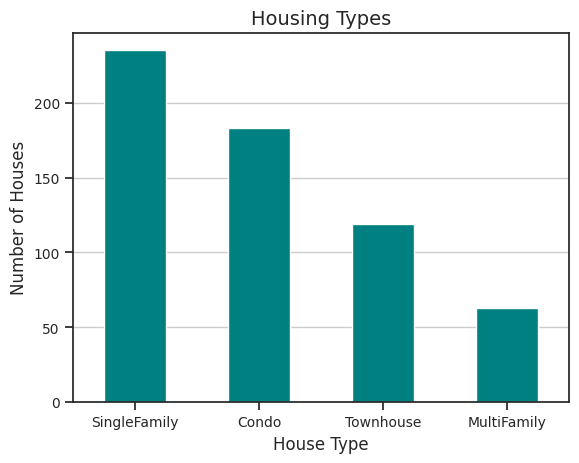

In [19]:
# Bar chart Housing Type
df['type'].value_counts().plot.bar(color='teal')
plt.xticks(rotation=0,fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('House Type', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)
plt.title('Housing Types',fontsize=14)
plt.grid(axis='y',zorder=0)
plt.show()

- Describe one interesting pattern you observe:

Median prices stay relatively similar accross neighborhoods, with the exception of Waterfront properties. This is interesting to see and aligns with the short tails we see in the pricing histogram. Even when comparing price ranges accross neighborhoods we see some significant overlap.  

### Step 0 - Create a Binary Outcome

In [48]:
#High price based on median of price:
df["high_price"] = (df["price"] > df["price"].median()).astype(int)

df.tail()

,listing_id,price,size,bedrooms,neighborhood,type,high_price
595,100596,232811.0,1443.241197,3.0,Midtown,Condo,1
596,100597,235624.0,1083.909714,2.0,Suburb,Condo,1
597,100598,244889.0,1600.126432,1.0,Suburb,SingleFamily,1
598,100599,239545.0,1248.216637,1.0,Waterfront,Condo,1
599,100600,257287.0,1450.981922,NaN,Suburb,SingleFamily,1


### Part A - Logistic Regression for Inference

In [49]:
model = smf.logit("high_price ~ size + bedrooms + C(neighborhood) + C(type)",data=df).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.683349
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.01414
Time:                        21:13:00   Log-Likelihood:                -358.07
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.3292
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.2590      0.309      0.837      0.

In [50]:
#table with coefficients, odds ratios, and p values
pd.DataFrame({"Coefficient":model.params,
              "Odds Ratio":np.exp(model.params),
              "P Value":model.pvalues})

,Coefficient,Odds Ratio,P Value
Intercept,0.259034,1.295677,0.402535
C(neighborhood)[T.Midtown],-0.265734,0.766643,0.352048
C(neighborhood)[T.Suburb],0.140164,1.150462,0.586668
C(neighborhood)[T.Uptown],0.055166,1.056716,0.842292
C(neighborhood)[T.Waterfront],0.432651,1.541338,0.223709
C(type)[T.MultiFamily],0.007946,1.007977,0.980126
C(type)[T.SingleFamily],0.116854,1.123955,0.603092
C(type)[T.Townhouse],0.320389,1.377664,0.213238
size,-0.000525,0.999475,0.036582
bedrooms,0.230827,1.259642,0.085279


- Which predictors appear statistically significant?

Based on this model - which takes into account neighborhood and housing type - size is the only significant predictor, with a p-value of ~0.0366. It is the only predictor with a p value lower than 0.05.

- Which neighborhood has higher odds of expensive homes?

The waterfront neighborhood. The odds ratio for that neighborhood is 1.54, which is higher than the other neighborhoods, indicating higher odds for higher prices (this aligns neatly with the boxplot information we saw for neighborhoods, where the median price for waterfront was the highest).  

### Part B - Interpretation

- Choose one variable and explain its odds ratio:

Odds ratios greater than one in this context indicate an increased chance of a house being considered high price (as defined by our binary). For the waterfront neighborhood, for example, we see an odds ratio of 1.54, indicating that if a house is in a waterfront neighborhood, it has a 54% increase in its odds of being considered high price.


### Part C - Prediction Workflow

In [51]:
#Split data into training and test sets
df1=df.dropna() #df has NaNs, dropping so I don't get an error
X = df1[["size","bedrooms", "neighborhood", "type"]]
y = df1['high_price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

#use get_dummies to encode cat. variables neighborhood and type (otherwise you get an error)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

#fit linear regression using scikit learn
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

Evaluate the Model

In [52]:
y_pred=model1.predict(X_test)
y_prob=model1.predict_proba(X_test)[:,1]

print(accuracy_score(y_test,y_pred))
print(roc_auc_score(y_test,y_prob))

0.5142857142857142
0.5501105379513633


Optional - Plot an ROC Curve

We didn't really go over this in class, so I mostly extrapolated from googling and multiple tries. Not sure if it's what we want.

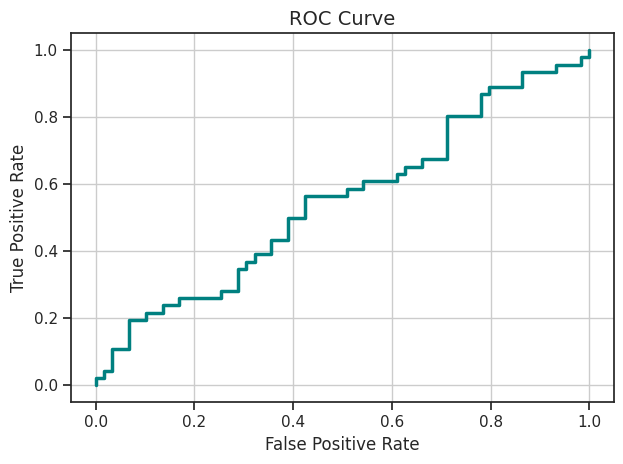

In [53]:

# Compute ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.plot(fpr, tpr, color="teal", linewidth=2.5, label=f"ROC curve (AUC = {auc:.3f})")

plt.title("ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.grid(True, zorder=0)
plt.tight_layout()
plt.show()


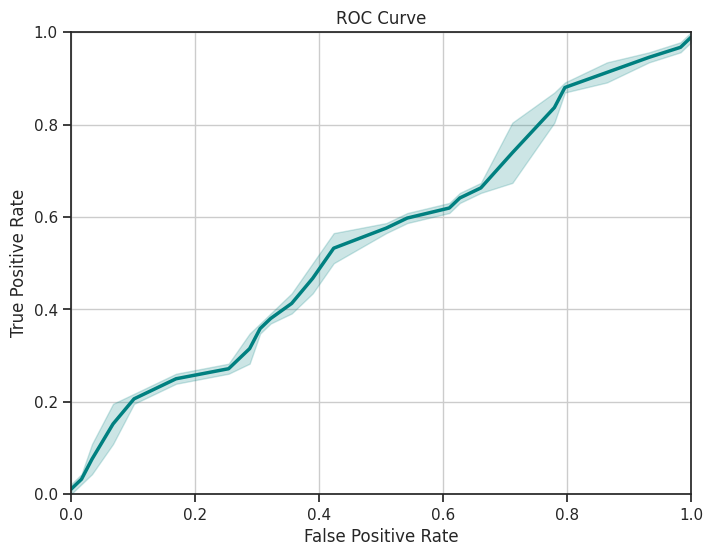

In [54]:
#Got an alternative way to plot using seaborn

# Put in a DataFrame (seaborn likes tidy data)
roc_df = pd.DataFrame({"FPR": fpr, "TPR": tpr})

# Plot with seaborn
sns.set_theme(style='ticks')
fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(data=roc_df, x="FPR", y="TPR", ax=ax, linewidth=2.5, color="teal")

ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.grid(True, zorder=0)
plt.show()


### Part D - Model Understanding

- Why might ROC-AUC be preferred over accuracy?

Accuracy is threshold dependent. ROC-AUC allow the evaluation of the model accorss all possible thresholds, so you get a better measure of how the model performs overall.

- Which modelling approach would you choose for:

  - Policy Analysis:

  I'd choose the statsmodel logistic regression. It evaluates the variables for significance and gives us confidence intervals so it is more focused on explaining what impact the variables have in the model than prediction.

  - Prediction Tasks:

  The prediction workflow with scikit learn is more suited to predition tasks - it is actually designed for prediction.